# 1. Business Problem

A SaaS company runs a retention campaign offering discounts to selected customers. 
The objective is to estimate the true causal impact of the intervention and identify which customers should be targeted to maximize retention ROI.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

sns.set(style="whitegrid")

# 2. Synthetic Data Generation

This dataset simulates customer-level features, treatment assignment, 
and churn outcomes with engineered confounding and heterogeneous treatment effects.

In [4]:
df = pd.read_csv("data/synthetic_retention_data.csv")

df.head()

,tenure,monthly_usage,support_tickets,engagement_score,plan_type,region,treatment,churn
0,5.631217,27.682074,1,0.591911,0,2,1,0
1,36.121457,33.122208,1,0.285689,0,0,1,0
2,15.800948,55.832284,6,0.536829,1,2,1,1
3,10.955311,32.391900,3,0.748480,0,1,0,1
4,2.035498,66.689515,0,0.410312,1,2,0,1


# 3. Naive Treatment Effect

Estimate the treatment effect using simple mean comparison 
without adjusting for confounding.

In [5]:
naive_ate = (
    df[df["treatment"] == 1]["churn"].mean() -
    df[df["treatment"] == 0]["churn"].mean()
)

print("Naive Treatment Effect:", naive_ate)

Naive Treatment Effect: -0.06919762168841093


# 4. Propensity Score Modeling

Model the probability of receiving treatment using logistic regression 
to estimate propensity scores.

In [6]:
features = [
    "tenure",
    "monthly_usage",
    "support_tickets",
    "engagement_score",
    "plan_type",
    "region"
]

X = df[features]
y = df["treatment"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

df["propensity_score"] = model.predict_proba(X_scaled)[:, 1]

roc_auc = roc_auc_score(y, df["propensity_score"])
print("Propensity Model AUC:", roc_auc)

Propensity Model AUC: 0.6752505362890493


In [7]:
df["iptw_weight"] = np.where(
    df["treatment"] == 1,
    1 / df["propensity_score"],
    1 / (1 - df["propensity_score"])
)

In [8]:
treated = df[df["treatment"] == 1]
control = df[df["treatment"] == 0]

weighted_ate = (
    np.average(treated["churn"], weights=treated["iptw_weight"]) -
    np.average(control["churn"], weights=control["iptw_weight"])
)

print("Naive ATE:", naive_ate)
print("IPTW Adjusted ATE:", weighted_ate)

Naive ATE: -0.06919762168841093
IPTW Adjusted ATE: -0.036887626140379215


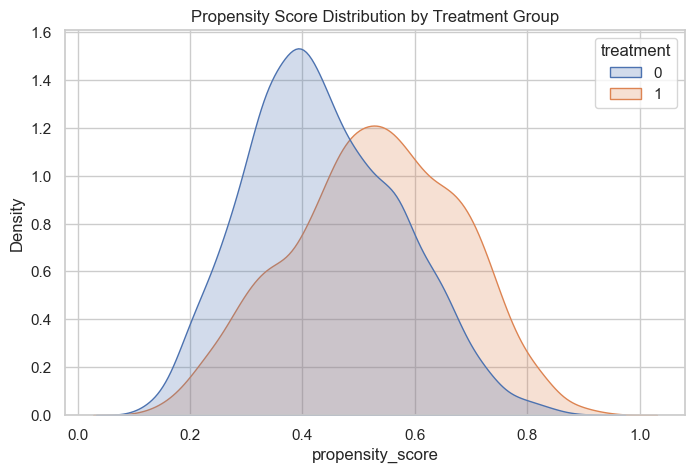

In [9]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="propensity_score", hue="treatment", fill=True)
plt.title("Propensity Score Distribution by Treatment Group")
plt.show()

# 5. Covariate Balance Check

Evaluate standardized mean differences before and after weighting 
to assess covariate balance.

In [10]:
def standardized_mean_diff(df, treatment_col, feature):
    treated = df[df[treatment_col] == 1][feature]
    control = df[df[treatment_col] == 0][feature]
    
    return (
        treated.mean() - control.mean()
    ) / np.sqrt((treated.var() + control.var()) / 2)

In [11]:
for col in features:
    smd = standardized_mean_diff(df, "treatment", col)
    print(f"{col}: {smd:.3f}")

tenure: 0.203
monthly_usage: 0.016
support_tickets: 0.007
engagement_score: 0.455
plan_type: 0.358
region: 0.018


# 6. IPTW Adjustment

Apply inverse propensity weighting to estimate the adjusted 
average treatment effect.

In [12]:
def weighted_mean(df, col):
    return np.average(df[col], weights=df["iptw_weight"])

for col in features:
    treated = df[df["treatment"] == 1]
    control = df[df["treatment"] == 0]
    
    smd_weighted = (
        weighted_mean(treated, col) -
        weighted_mean(control, col)
    ) / np.sqrt((treated[col].var() + control[col].var()) / 2)
    
    print(f"{col} (weighted): {smd_weighted:.3f}")

tenure (weighted): 0.001
monthly_usage (weighted): -0.002
support_tickets (weighted): -0.000
engagement_score (weighted): -0.026
plan_type (weighted): -0.003
region (weighted): 0.001


# 7. Uplift Modeling

Train separate outcome models for treated and control groups 
to estimate individual treatment effects.

In [14]:
treated_df = df[df["treatment"] == 1]
control_df = df[df["treatment"] == 0]

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_treated = RandomForestClassifier(n_estimators=200, random_state=42)
rf_control = RandomForestClassifier(n_estimators=200, random_state=42)

rf_treated.fit(treated_df[features], treated_df["churn"])
rf_control.fit(control_df[features], control_df["churn"])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
df["pred_churn_treated"] = rf_treated.predict_proba(df[features])[:, 1]
df["pred_churn_control"] = rf_control.predict_proba(df[features])[:, 1]

df["uplift_score"] = df["pred_churn_control"] - df["pred_churn_treated"]

# 8. Uplift Decile Analysis

Rank customers by predicted uplift and analyze treatment 
effect concentration across deciles.

In [17]:
df_sorted = df.sort_values(by="uplift_score", ascending=False)
df_sorted.head()

,tenure,monthly_usage,support_tickets,engagement_score,plan_type,region,treatment,churn,propensity_score,iptw_weight,pred_churn_treated,pred_churn_control,uplift_score
6603,19.747437,60.770931,1,0.192749,1,1,1,0,0.387185,2.582747,0.095,0.865,0.77
3139,0.850977,38.860113,1,0.322813,1,2,1,0,0.402714,2.483154,0.125,0.875,0.75
8037,23.181317,56.015875,2,0.289330,0,2,0,1,0.308311,1.445736,0.220,0.960,0.74
3206,23.487900,57.830310,3,0.590471,0,2,1,0,0.543114,1.841235,0.160,0.900,0.74
7117,0.817160,47.020968,1,0.229167,1,2,1,0,0.334176,2.992432,0.165,0.905,0.74


In [18]:
top_20 = df_sorted.head(int(0.2 * len(df)))

top_20["uplift_score"].mean()

np.float64(0.467915)

In [19]:
top_segment_ate = (
    top_20[top_20["treatment"] == 1]["churn"].mean() -
    top_20[top_20["treatment"] == 0]["churn"].mean()
)

print("ATE in Top 20% Uplift Segment:", top_segment_ate)

ATE in Top 20% Uplift Segment: -1.0


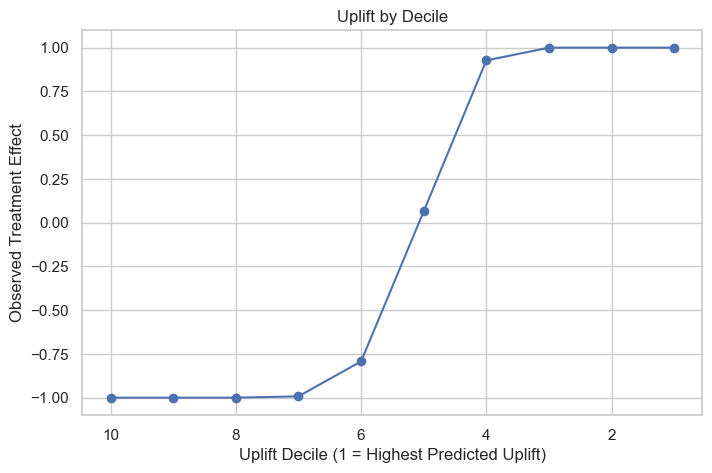

In [21]:
# Create deciles based on uplift ranking
df_sorted["percentile"] = pd.qcut(
    df_sorted["uplift_score"].rank(method="first"),
    10,
    labels=False
)

uplift_by_decile = []

for i in range(10):
    segment = df_sorted[df_sorted["percentile"] == i]
    
    ate_segment = (
        segment[segment["treatment"] == 1]["churn"].mean() -
        segment[segment["treatment"] == 0]["churn"].mean()
    )
    
    uplift_by_decile.append(ate_segment)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), uplift_by_decile, marker="o")
plt.xlabel("Uplift Decile (1 = Highest Predicted Uplift)")
plt.ylabel("Observed Treatment Effect")
plt.title("Uplift by Decile")
plt.gca().invert_xaxis()
plt.show()

# 9. Business Insights

## Key Findings

- Naive ATE estimated a -6.9% reduction in churn.
- After correcting for confounding using IPTW, the adjusted ATE reduced to approximately -3.7%.
- Significant covariate imbalance (SMD up to 0.45) was reduced to near-zero after weighting.
- Treatment impact is highly heterogeneous across customers.
- The top uplift deciles show substantially stronger treatment response than the population average.
- Lower deciles demonstrate negligible or negative treatment effects.

## Strategic Recommendation

Rather than offering discounts to all customers:

- Target the top 20–30% uplift segment.
- Avoid intervening on low- or negative-response users.
- This improves retention ROI and prevents unnecessary revenue leakage.

## Conclusion

This analysis demonstrates the importance of:
- Correcting for selection bias,
- Estimating causal impact rather than correlation,
- Leveraging uplift modeling to optimize business strategy.